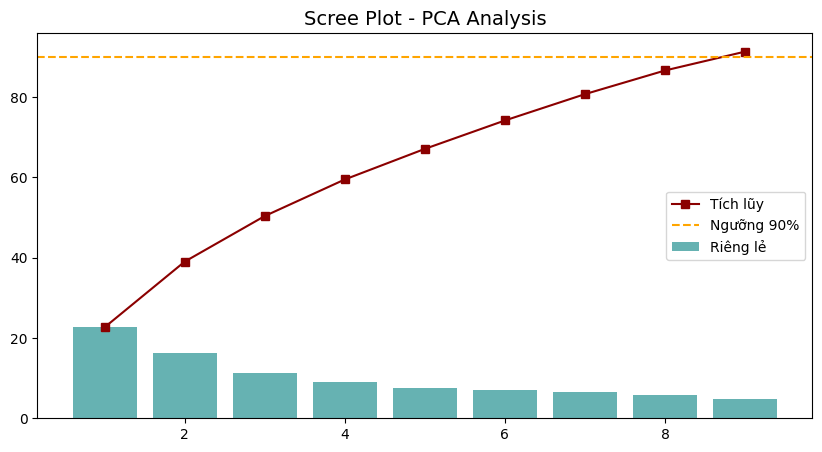

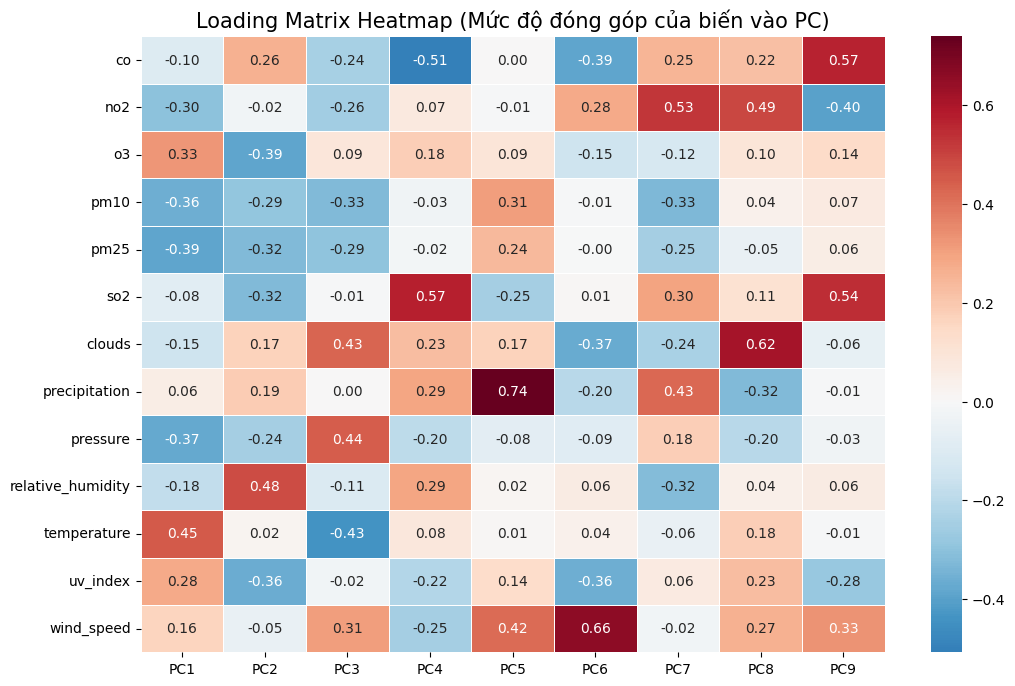

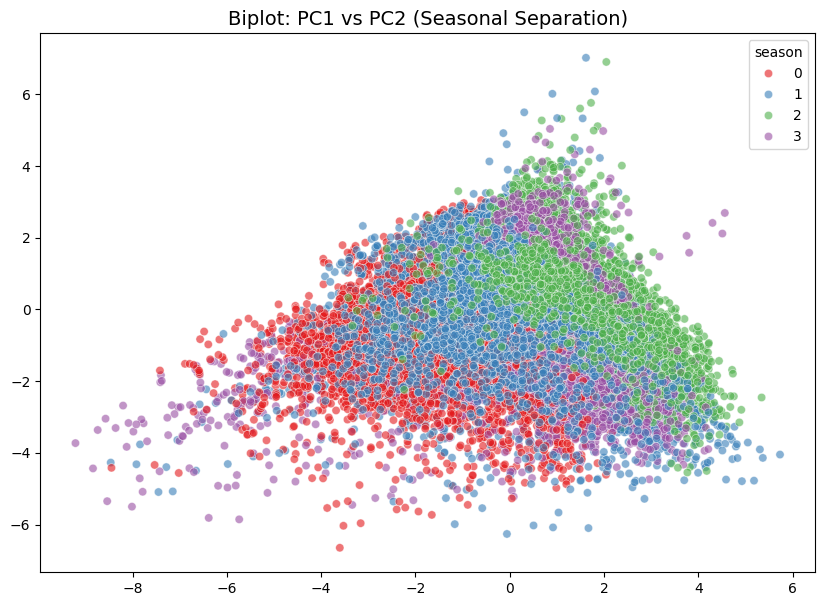

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Đọc dữ liệu và xử lý tên cột
df = pd.read_csv('../clean/hanoi_aqi_cleaned.csv')
df.columns = df.columns.str.strip().str.lower()

# 2. Chọn 13 biến khí tượng (Xử lý Missing bằng Median)
target_cols = ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'clouds', 
               'precipitation', 'pressure', 'relative_humidity', 
               'temperature', 'uv_index', 'wind_speed']
X = df[target_cols].apply(pd.to_numeric, errors='coerce').fillna(df[target_cols].median(numeric_only=True))

# 3. Chuẩn hóa và chạy PCA 9 thành phần
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=9)
X_pca = pca.fit_transform(X_scaled)
exp_var = pca.explained_variance_ratio_ * 100

# --- VẼ BIỂU ĐỒ 1: SCREE PLOT ---
plt.figure(figsize=(10, 5))
plt.bar(range(1, 10), exp_var, alpha=0.6, color='teal', label='Riêng lẻ')
plt.plot(range(1, 10), np.cumsum(exp_var), marker='s', color='darkred', label='Tích lũy')
plt.axhline(y=90, color='orange', linestyle='--', label='Ngưỡng 90%')
plt.title('Scree Plot - PCA Analysis', fontsize=14)
plt.legend()
plt.show()

# --- VẼ BIỂU ĐỒ 2: LOADING MATRIX HEATMAP 
loadings = pd.DataFrame(pca.components_.T, index=target_cols, columns=[f'PC{i+1}' for i in range(9)])
plt.figure(figsize=(12, 8))
sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title('Loading Matrix Heatmap (Mức độ đóng góp của biến vào PC)', fontsize=15)
plt.show()

# --- VẼ BIỂU ĐỒ 3: BIPLOT THEO MÙA ---
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['season'], palette='Set1', alpha=0.6)
plt.title('Biplot: PC1 vs PC2 (Seasonal Separation)', fontsize=14)
plt.show()